# Forecasting based detection of anomalies

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from ipywidgets import interact

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

SEQ_LEN = 300 
BATCH_SIZE = 64

## Data loading and viz

In [3]:
# 1. Load Data
with open('data/final_models_input/train_dataset.pkl', 'rb') as f:
    train_data = pickle.load(f)
    
with open('data/final_models_input/test_dataset.pkl', 'rb') as f:
    test_data = pickle.load(f)

X_train_raw = train_data['X'] # Shape: (N, 1500, 4)
X_test_raw = test_data['X']

# 1. Define Feature Names (Based on your input order)
# Adjust these if your order was different!
feature_map = {
    "0: Active Power": 0,
    "1: Guide Vane Position": 1,
    "2: Water Pressure Downstream": 2,
    "3: Water Pressure Upstream": 3
}

# 2. Extract Durations for Visualization
# We assume train_data was loaded as per your snippet
train_durations = train_data['durations']
# train_durations = test_data['durations']

def inspect_training_sample(sample_index, feature_name):
    # Get Feature Index
    feat_idx = feature_map[feature_name]
    
    # Get Data
    signal_data = X_train_raw[sample_index, :, feat_idx]
    
    # Get Original Duration (to visualize where padding starts)
    # The duration is in seconds, data is 10Hz, so index = duration * 10
    original_end_index = int(train_durations[sample_index] * 10)
    
    # --- Plotting ---
    plt.figure(figsize=(12, 5))
    
    # Plot the signal
    plt.plot(signal_data, color='blue', linewidth=1.5, label='Sensor Signal')
    
    # TODO: Fix this plotting to show the actual end of real data, right now it is wrong!!
    # Plot the "End of Real Data" line
    if original_end_index < 1500:
        plt.axvline(x=original_end_index, color='red', linestyle='--', linewidth=2, label='End of Real Data / Start of Padding')
        # Highlight the padded area
        plt.axvspan(original_end_index, 1500, color='yellow', alpha=0.1, label='Padded Region')
        
    plt.title(f"Sample #{sample_index}: {feature_name}", fontsize=14)
    plt.ylabel("Value (Raw Scale)")
    plt.xlabel("Time Steps (0.1s)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

# 3. Create Interactive Widgets
interact(inspect_training_sample, 
         sample_index=widgets.IntSlider(min=0, max=len(X_train_raw)-1, step=1, value=0, description='Sample ID'),
         feature_name=widgets.Dropdown(options=feature_map.keys(), value="2: Water Pressure Downstream", description='Feature'));

interactive(children=(IntSlider(value=0, description='Sample ID', max=2459), Dropdown(description='Feature', i…

## Data loading and normalization

In [6]:
# 2. Normalization (MinMax 0-1)
# We flatten the time dimension to fit the scaler, then reshape back
N, T, F = X_train_raw.shape
scaler = MinMaxScaler()

# Flatten -> Fit -> Reshape
X_train_flat = X_train_raw.reshape(-1, F)
scaler.fit(X_train_flat)
X_train_scaled = scaler.transform(X_train_flat).reshape(N, T, F)
X_train = X_train_scaled[:, ::5, :] # Downsample to 300 timesteps

# Apply same scaler to Test data
X_test_flat = X_test_raw.reshape(-1, F)
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test_raw.shape[0], T, F)
X_test_scaled = X_test_scaled[:, ::5, :] # Downsample to 300 timesteps

# 3. Convert to PyTorch Tensors
tensor_x = torch.Tensor(X_train_scaled) # Shape: [N, 1500, 4]

# A. Create the Full Dataset first
full_dataset = TensorDataset(tensor_x)

# B. Calculate split sizes
val_size = int(len(tensor_x) * 0.15)
train_size = len(tensor_x) - val_size

# C. Split the DATASET (not the tensor)
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# D. Create Loaders
# Note: We pass 'train_subset' directly, no TensorDataset() wrapper needed here
batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

print(f"Data Loaded Successfully.")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Data Loaded Successfully.
Train batches: 33
Val batches: 6


## Define the forecasting model

In [5]:

# class LSTMForecaster(nn.Module):
#     def __init__(self, n_features=4, hidden_dim=128, num_layers=2):
#         super(LSTMForecaster, self).__init__()
        
#         # Standard LSTM
#         # batch_first=True -> (Batch, Seq, Feature)
#         self.lstm = nn.LSTM(
#             input_size=n_features, 
#             hidden_size=hidden_dim, 
#             num_layers=num_layers, 
#             batch_first=True,
#             dropout=0.2
#         )
        
#         # Output layer
#         # Maps hidden state at every step to the *Predicted Value* of the next step
#         self.head = nn.Linear(hidden_dim, n_features)
        
#     def forward(self, x):
#         # x shape: (Batch, Seq_Len, Features)
        
#         # LSTM processes the sequence
#         # out shape: (Batch, Seq_Len, Hidden_Dim)
#         out, _ = self.lstm(x)
        
#         # Predict values
#         # prediction shape: (Batch, Seq_Len, Features)
#         prediction = self.head(out)
        
#         return prediction

class LSTMForecaster(nn.Module):
    def __init__(self, n_features=4, hidden_dim=128):
        super(LSTMForecaster, self).__init__()
        # 2 Layers to learn complex physics
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_dim, 
                            num_layers=2, batch_first=True, dropout=0.2)
        # Maps hidden state to the PREDICTED values
        self.head = nn.Linear(hidden_dim, n_features)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        pred = self.head(out)
        return pred

## Training

In [7]:
# CONFIG
model = LSTMForecaster(n_features=4, hidden_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss() # MSE is good for forecasting exact values

# TRAINING LOOP
for epoch in range(50):
    model.train()
    train_loss = 0
    
    for batch in train_loader:
        # Load batch: (Batch, 300, 4)
        x = batch[0].to(device)
        
        # === THE SHIFT ===
        # Input: Everything except the very last time step
        # Target: Everything except the very first time step
        x_input  = x[:, :-1, :]  # Steps 0..298
        y_target = x[:, 1:, :]   # Steps 1..299
        
        # Forward
        prediction = model(x_input)
        
        # Loss
        loss = criterion(prediction, y_target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    print(f"Epoch {epoch+1}: Loss {train_loss:.6f}")

Epoch 1: Loss 2.474390
Epoch 2: Loss 0.588505
Epoch 3: Loss 0.178290
Epoch 4: Loss 0.107743
Epoch 5: Loss 0.061510
Epoch 6: Loss 0.047388
Epoch 7: Loss 0.037142
Epoch 8: Loss 0.023750
Epoch 9: Loss 0.021406
Epoch 10: Loss 0.020212
Epoch 11: Loss 0.019302
Epoch 12: Loss 0.018487
Epoch 13: Loss 0.017703
Epoch 14: Loss 0.017019
Epoch 15: Loss 0.016402
Epoch 16: Loss 0.015845
Epoch 17: Loss 0.015284
Epoch 18: Loss 0.014784
Epoch 19: Loss 0.014282
Epoch 20: Loss 0.013847
Epoch 21: Loss 0.013429
Epoch 22: Loss 0.012997
Epoch 23: Loss 0.012553
Epoch 24: Loss 0.012151
Epoch 25: Loss 0.011805
Epoch 26: Loss 0.011435
Epoch 27: Loss 0.011060
Epoch 28: Loss 0.010656
Epoch 29: Loss 0.010468
Epoch 30: Loss 0.009999
Epoch 31: Loss 0.009677
Epoch 32: Loss 0.009403
Epoch 33: Loss 0.009162
Epoch 34: Loss 0.008920
Epoch 35: Loss 0.008751
Epoch 36: Loss 0.008620
Epoch 37: Loss 0.008228
Epoch 38: Loss 0.007916
Epoch 39: Loss 0.007836
Epoch 40: Loss 0.008201
Epoch 41: Loss 0.007423
Epoch 42: Loss 0.007141
E

## Save model

In [8]:
# 1. Save Model Weights
torch.save(model.state_dict(), 'forecasting_model.pth')

# 2. Save Scaler (Important!)
with open('data/final_models_input/forecasting_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and Scaler saved successfully.")

Model and Scaler saved successfully.


## Evaluation

In [9]:
DATA_PATH = 'data/final_models_input/train_dataset_with_anomalies.pkl' # Raw generated anomaly data
SCALER_PATH = 'data/final_models_input/forecasting_scaler.pkl'
MODEL_PATH = 'forecasting_model.pth'

def evaluate_forecaster():
    # 1. Load Data
    print("Loading Data & Scaler...")
    with open(DATA_PATH, 'rb') as f:
        data = pickle.load(f)
        X_raw = data['X']
        y_labels = data['y'] # 0=Normal, 1=Leak, 2=Offset, 3=Drift
        
    with open(SCALER_PATH, 'rb') as f:
        scaler = pickle.load(f)
        
    # 2. Preprocess
    print("Preprocessing...")
    N, T, F = X_raw.shape
    X_flat = X_raw.reshape(-1, F)
    X_scaled = scaler.transform(X_flat).reshape(N, T, F)
    X_downsampled = X_scaled[:, ::5, :] # 1500 -> 300
    
    tensor_x = torch.FloatTensor(X_downsampled).to(device)
    loader = DataLoader(TensorDataset(tensor_x), batch_size=batch_size, shuffle=False)

    model.eval()
    all_scores = []
    
    # We still use K=30 (Look for worst 10% of predictions)
    K_STEPS = 30 
    
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            
            # Prepare Input/Target
            x_input  = x[:, :-1, :]
            y_target = x[:, 1:, :]
            
            # Forecast
            preds = model(x_input)
            
            # --- SCORING ---
            # 1. Prediction Error
            error = torch.abs(y_target - preds)
            
            # 2. Sum over features
            error_sum = torch.sum(error, dim=2)
            
            # 3. Top-K Mean
            top_k, _ = torch.topk(error_sum, k=K_STEPS, dim=1)
            score = torch.mean(top_k, dim=1)
            
            all_scores.extend(score.cpu().numpy())

    all_scores = np.array(all_scores)
        
    # 5. Determine Threshold (Using only Normal Data)
    # Strategy: Threshold = Mean + 3 StdDev of Normal Data
    normal_indices = np.where(y_labels == 0)[0]
    normal_scores = all_scores[normal_indices]
    
    threshold = np.mean(normal_scores) + 3 * np.std(normal_scores)
    # Alternatively: Use 99th percentile to be safer against outliers
    # threshold = np.percentile(normal_scores, 99)
    
    print(f"\n--- THRESHOLD SETTING ---")
    print(f"Normal Mean Score: {np.mean(normal_scores):.5f}")
    print(f"Normal Max Score:  {np.max(normal_scores):.5f}")
    print(f"Calculated Threshold: {threshold:.5f}")

    # 6. Updated Fault Mapping
    # Based on the order in 'generate_comprehensive_anomalies'
    fault_names = {
        0: "Normal", 
        1: "Seal Leakage", 
        2: "Delayed Closure", 
        3: "Sensor Offset", 
        4: "Sensor Drift",
        5: "Water Hammer",
        6: "Stick-Slip/Jerky",
        7: "PID Hunting",
        8: "Signal Dropout"
    }
    
    # Define Colors for plotting
    colors = {
        0: 'blue',      # Normal
        1: 'red',       # Leak
        2: 'purple',    # Delay
        3: 'orange',    # Offset
        4: 'green',     # Drift
        5: 'brown',     # Hammer
        6: 'magenta',   # Jerky
        7: 'black',      # PID Hunting
        8: 'cyan'       # Signal Dropout
    }

    # 7. Print Table
    print(f"\n{'Fault Type':<20} | {'Detected':<10} | {'Avg Score':<10}")
    print("-" * 50)
    
    unique_labels = np.sort(np.unique(y_labels))
    
    for lbl in unique_labels:
        idxs = np.where(y_labels == lbl)[0]
        sc = all_scores[idxs]
        
        # Detection Rate
        detected_count = np.sum(sc > threshold)
        rate = detected_count / len(sc) * 100
        
        name = fault_names.get(lbl, f"Type {lbl}")
        print(f"{name:<20} | {rate:>8.1f}% | {np.mean(sc):.5f}")

    # 8. Visualization (Histograms)
    plt.figure(figsize=(12, 6))
    
    # Plot Normal first to be at the back
    lbl = 0
    plt.hist(all_scores[y_labels == lbl], bins=50, alpha=0.3, 
             label=fault_names[lbl], color=colors[lbl], density=True)

    # Plot Anomalies
    for lbl in unique_labels:
        if lbl == 0: continue
        plt.hist(all_scores[y_labels == lbl], bins=50, alpha=0.5, 
                 label=fault_names.get(lbl, f"Type {lbl}"), 
                 color=colors.get(lbl, 'gray'), density=True)
    
    plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label='Threshold')
    plt.title(f"Anomaly Score Distribution (Top-{K_STEPS} Metric)")
    plt.xlabel("Reconstruction Error Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Loading Data & Scaler...
Preprocessing...

--- THRESHOLD SETTING ---
Normal Mean Score: 0.20570
Normal Max Score:  0.43791
Calculated Threshold: 0.25294

Fault Type           | Detected   | Avg Score 
--------------------------------------------------
Normal               |      1.2% | 0.20570
Seal Leakage         |      1.2% | 0.21168
Delayed Closure      |      1.2% | 0.20574
Sensor Offset        |    100.0% | 0.56917
Sensor Drift         |      1.4% | 0.21911
Water Hammer         |     99.8% | 0.32816
Stick-Slip/Jerky     |      1.2% | 0.20475
PID Hunting          |      1.2% | 0.20570
Signal Dropout       |     11.6% | 0.22928


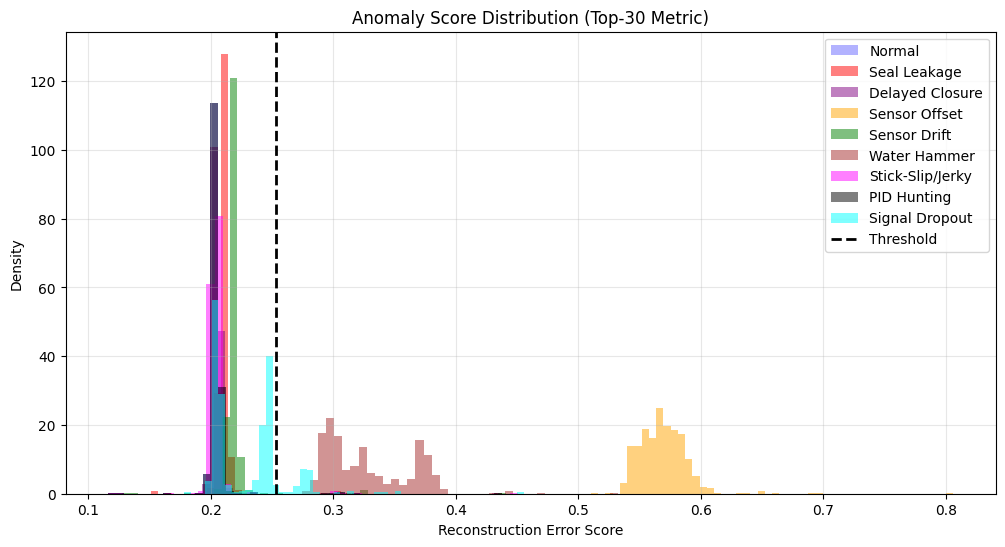

In [10]:
evaluate_forecaster()